# 🏠 Amsterdam Airbnb Analytics
### E628: Data Science for Business — Final Group Project
**Data:** [Inside Airbnb](http://insideairbnb.com/get-the-data/) · Amsterdam

---

### 📋 Rubric Alignment

| # | Section | Rubric Dimension | Points |
|---|---------|-----------------|--------|
| 2 | Data Loading | **1. Data Acquisition & Wrangling** | 20 |
| 3 | Cleaning & Feature Engineering | **1. Data Acquisition & Wrangling** | 20 |
| 4–7 | EDA, Pricing, Sentiment, Geography | **2. EDA** | 20 |
| 8–9 | Linear Regression + XGBoost + SHAP | **3. Machine Learning Modelling** | 25 |
| 10 | Interactive App / Dashboard | **4. Interactive App / Dashboard** | 15 |
| 11 | Storytelling & Communication | **5. Storytelling & Communication** | 10 |
| 12 | Critical Thinking & Reflection | **6. Critical Thinking & Reflection** | 10 |

---

**Conventions:**  
- All transformations use **pandas method chaining** — `.pipe()`, `.assign()`, `.query()`.  
- **Seaborn** for all plots with a consistent Airbnb colour palette.  
- Comments explain *why*, not just *what*. Notebook reruns top-to-bottom without errors.

---
## 1. Setup & Configuration

In [2]:
import gzip, io, re, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import folium
from folium.plugins import HeatMap, MarkerCluster
from textblob import TextBlob
from wordcloud import WordCloud
import requests

from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', '{:.2f}'.format)

# ── Consistent Airbnb palette across ALL charts (rubric: consistent styling) ─
# https://www.onlinepalette.com/airbnb/
AIRBNB_PALETTE = ['#FF5A5F', '#00A699', '#FC642D', '#484848', '#767676', '#FFB400']

sns.set_theme(style='whitegrid', palette=AIRBNB_PALETTE, font_scale=1.1)
plt.rcParams['figure.figsize'] = (12, 5)

# ── All URLs and constants centralised — no hard-coded magic numbers elsewhere
#  URLs for different cities can be be found at https://insideairbnb.com/get-the-data/
CITY_NAME    = 'Amsterdam'
LISTINGS_URL = 'https://data.insideairbnb.com/the-netherlands/north-holland/amsterdam/2025-09-11/data/listings.csv.gz'
REVIEWS_URL  = 'https://data.insideairbnb.com/the-netherlands/north-holland/amsterdam/2025-09-11/data/reviews.csv.gz'

# We need the neighbourhood GeoJSON that Inside Airbnb publishes 
GEOJSON_URL = 'https://data.insideairbnb.com/the-netherlands/north-holland/amsterdam/2025-09-11/visualisations/neighbourhoods.geojson'

SEED         = 123

print(f'Setup complete — analysing {CITY_NAME}')

Setup complete — analysing Amsterdam


---
## 2. Data Acquisition


In [3]:
def load_gz_csv(url: str) -> pd.DataFrame:
    """
    Stream-download a gzip-compressed CSV from Inside Airbnb.
    Source: Inside Airbnb (http://insideairbnb.com/get-the-data/)
    Centralised here so the pipeline reruns top-to-bottom without manual steps.
    """
    print(f'  Downloading {url.split("/")[-1]} ...', end=' ')
    r = requests.get(url, timeout=120)
    r.raise_for_status()
    df = pd.read_csv(gzip.open(io.BytesIO(r.content)), low_memory=False)
    print(f'{len(df):,} rows x {df.shape[1]} cols')
    return df

print(f'Loading Inside Airbnb data for {CITY_NAME}...')
listings_raw = load_gz_csv(LISTINGS_URL)
reviews_raw  = load_gz_csv(REVIEWS_URL)
print('\nListing columns:', listings_raw.columns.tolist())
print('\nReviews columns:', reviews_raw.columns.tolist())

Loading Inside Airbnb data for Amsterdam...

Listing columns: ['id', 'listing_url', 'scrape_id', 'last_scraped', 'source', 'name', 'description', 'neighborhood_overview', 'picture_url', 'host_id', 'host_url', 'host_name', 'host_since', 'host_location', 'host_about', 'host_response_time', 'host_response_rate', 'host_acceptance_rate', 'host_is_superhost', 'host_thumbnail_url', 'host_picture_url', 'host_neighbourhood', 'host_listings_count', 'host_total_listings_count', 'host_verifications', 'host_has_profile_pic', 'host_identity_verified', 'neighbourhood', 'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'latitude', 'longitude', 'property_type', 'room_type', 'accommodates', 'bathrooms', 'bathrooms_text', 'bedrooms', 'beds', 'amenities', 'price', 'minimum_nights', 'maximum_nights', 'minimum_minimum_nights', 'maximum_minimum_nights', 'minimum_maximum_nights', 'maximum_maximum_nights', 'minimum_nights_avg_ntm', 'maximum_nights_avg_ntm', 'calendar_updated', 'has_availability', 'avai

---
## 3. Data Cleaning & Feature Engineering


All cleaning is expressed as a **single pandas method chain** — each `.pipe()` is a named, testable function.

In [4]:
# ── Modular helper functions — each does exactly one thing ───────────────────

def parse_price(df: pd.DataFrame) -> pd.DataFrame:
    """Strip currency symbols and commas, then coerce to float."""
    return df.assign(
        price=lambda x: (
            x['price'].astype(str)
            .str.replace(r'[\$€,]', '', regex=True)
            .pipe(pd.to_numeric, errors='coerce')
        )
    )


def parse_numeric_cols(df: pd.DataFrame) -> pd.DataFrame:
    """Coerce columns that should be numeric but may arrive as strings."""
    cols = [
        'review_scores_rating', 'review_scores_cleanliness',
        'review_scores_communication', 'review_scores_location',
        'review_scores_value', 'accommodates', 'bedrooms', 'beds',
        'minimum_nights', 'number_of_reviews',
        'calculated_host_listings_count', 'latitude', 'longitude'
    ]
    existing = [c for c in cols if c in df.columns]
    return df.assign(**{c: pd.to_numeric(df[c], errors='coerce') for c in existing})


def add_derived_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Engineer business-meaningful features — each justified below.
    No unexplained derivations (rubric: comments explaining why).
    """
    return df.assign(
        # Price per person: group-size normalisation for fairer neighbourhood comparisons
        price_per_person=lambda x: x['price'] / x['accommodates'].replace(0, np.nan),
        # Host tenure: experience proxy — senior hosts may price differently
        host_age_years=lambda x: (
            (pd.Timestamp.now() - pd.to_datetime(x.get('host_since'), errors='coerce'))
            .dt.days / 365
        ),
        # Identity verification: trust signal that may affect bookings
        host_identity_verified=lambda x: (
            x.get('host_identity_verified', pd.Series('f', index=x.index))
             .map({'t': 1, 'f': 0})
        ),
        # Superhost: official Airbnb quality badge — potential quality premium
        is_superhost=lambda x: (
            x.get('host_is_superhost', pd.Series('f', index=x.index))
             .map({'t': 1, 'f': 0})
        ),
        # Log-price: raw price is right-skewed; log transform yields near-normality
        # and satisfies linear regression's homoscedasticity assumption better
        log_price=lambda x: np.log1p(x['price'])
    )


def handle_missing_values(df: pd.DataFrame) -> pd.DataFrame:
    """
    Justified missing-value strategy:
    - latitude/longitude DROPPED: cannot map or model without coordinates.
    - price DROPPED: it's the target variable; imputation would bias the model.
    All other NaNs are left for sklearn imputers INSIDE the ML pipeline,
    which imputes within CV folds — preventing data leakage.
    """
    return df.dropna(subset=['latitude', 'longitude', 'price'])


def filter_price_outliers(df: pd.DataFrame, lo: float = 15, hi: float = 1000) -> pd.DataFrame:
    """
    Remove extreme prices:
    <€15: likely data-entry errors or private arrangements, not market listings.
    >€1000: ultra-luxury outliers (<0.5% of data) that distort distribution plots.
    """
    return df.query('@lo <= price <= @hi')


# ── Single chain — readable, testable, reproducible ──────────────────────────
df = (
    listings_raw
    .pipe(parse_price)             # 1. clean price string to float
    .pipe(parse_numeric_cols)      # 2. enforce numeric dtypes
    .pipe(add_derived_features)    # 3. engineer new features
    .pipe(handle_missing_values)   # 4. drop unusable rows (justified above)
    .pipe(filter_price_outliers)   # 5. remove extreme price outliers
    .reset_index(drop=True)        # 6. clean integer index
)

print(f'Clean dataset: {len(df):,} listings')
print(f'Neighbourhoods: {df["neighbourhood_cleansed"].nunique()}')
print(f'Room types: {df["room_type"].value_counts().to_dict()}')
df[['price', 'accommodates', 'bedrooms', 'review_scores_rating', 'host_age_years']].describe().T

Clean dataset: 5,819 listings
Neighbourhoods: 22
Room types: {'Entire home/apt': 4485, 'Private room': 1271, 'Hotel room': 33, 'Shared room': 30}


,count,mean,std,min,25%,50%,75%,max
price,5819.00,253.17,139.87,35.00,161.00,220.00,309.00,1000.00
accommodates,5819.00,2.92,1.32,1.00,2.00,2.00,4.00,16.00
bedrooms,5810.00,1.48,0.85,0.00,1.00,1.00,2.00,10.00
review_scores_rating,5178.00,4.84,0.26,1.00,4.78,4.91,5.00,5.00
host_age_years,5817.00,9.45,3.47,0.51,7.41,10.24,11.97,17.42


In [5]:
# ── Missing-value audit post-clean — transparent documentation for reviewers ─
(
    df.isnull().sum()
    .pipe(lambda s: s[s > 0])
    .sort_values(ascending=False)
    .rename('n_missing')
    .to_frame()
    .assign(pct=lambda x: (x['n_missing'] / len(df) * 100).round(1))
    .head(20)
)

,n_missing,pct
neighbourhood_group_cleansed,5819,100.00
calendar_updated,5819,100.00
host_neighbourhood,4394,75.50
neighbourhood,3096,53.20
neighborhood_overview,3096,53.20
host_about,2728,46.90
host_response_time,841,14.50
host_response_rate,841,14.50
host_location,677,11.60
review_scores_cleanliness,641,11.00


---
## 4. Exploratory Data Analysis (EDA)

> Systematic multi-angle exploration; variety of chart types (histograms, heatmap, box plots, time-series, bubble chart); statistical summaries complement visualisations; outliers investigated with domain reasoning; curiosity shown beyond minimum requirements.

**Business question:** *What drives nightly prices on Amsterdam Airbnb, and how does listing quality vary across the city?*

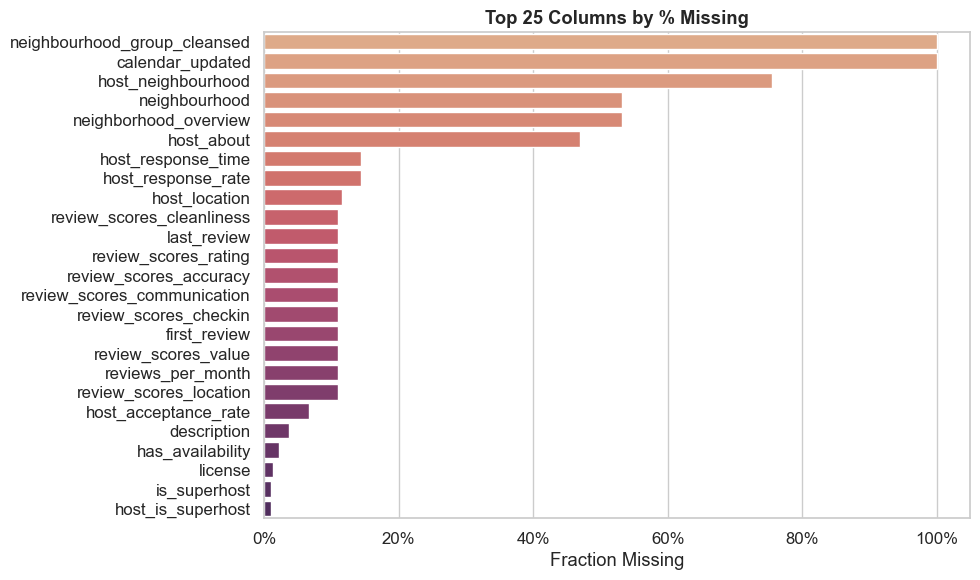

In [6]:
# ── 4.1 Missingness heatmap ───────────────────────────────────────────────────
# Informs which columns need imputation in the ML pipeline
miss = (
    df.isnull().mean()
    .pipe(lambda s: s[s > 0])
    .sort_values(ascending=False)
    .head(25)
    .rename('pct_missing')
    .to_frame()
)
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=miss.reset_index(), x='pct_missing', y='index', palette='flare', ax=ax)
ax.set_title('Top 25 Columns by % Missing', fontweight='bold')
ax.set_xlabel('Fraction Missing'); ax.set_ylabel('')
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
plt.tight_layout(); plt.show()

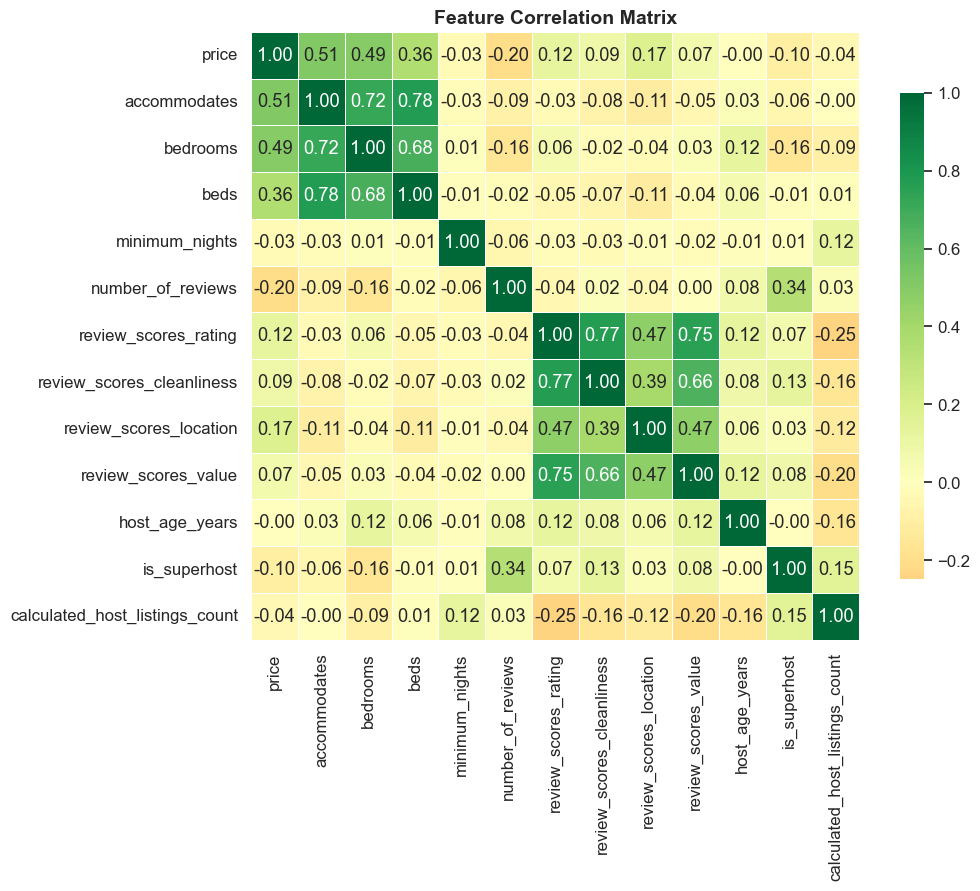

In [12]:
# ── 4.2 Correlation matrix ────────────────────────────────────────────────────
# Shows linear relationships between numeric features and price;
# review scores are highly co-linear — important for model design choices
corr_cols = [
    'price', 'accommodates', 'bedrooms', 'beds', 'minimum_nights',
    'number_of_reviews', 'review_scores_rating', 'review_scores_cleanliness',
    'review_scores_location', 'review_scores_value',
    'host_age_years', 'is_superhost', 'calculated_host_listings_count'
]
corr_cols = [c for c in corr_cols if c in df.columns]
corr_matrix = df[corr_cols].dropna().corr()

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(
    corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
    center=0, linewidths=0.5, square=True,
    cbar_kws={'shrink': 0.8}, ax=ax
)
ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

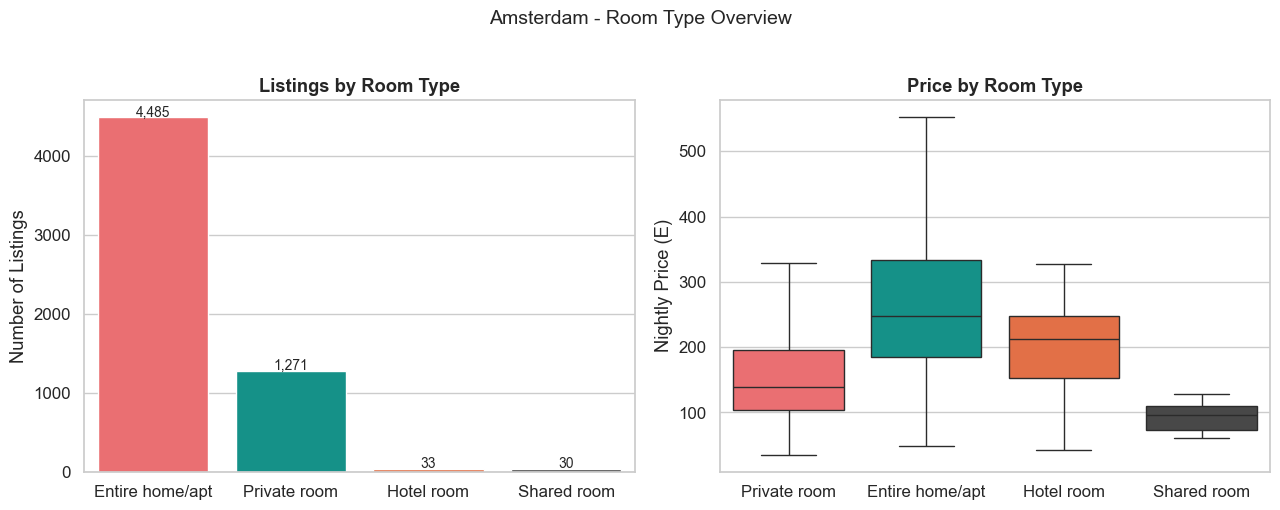

In [14]:
# ── 4.3 Room-type breakdown (count + price distribution) ─────────────────────
room_counts = df['room_type'].value_counts().reset_index().rename(columns={'count': 'n_listings'})

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.barplot(data=room_counts, 
    x='room_type', 
    y='n_listings', 
    palette=AIRBNB_PALETTE, 
    ax=axes[0])
axes[0].set_title('Listings by Room Type', fontweight='bold')
axes[0].set_xlabel(''); axes[0].set_ylabel('Number of Listings')
for bar in axes[0].patches:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
                 f'{int(bar.get_height()):,}', ha='center', fontsize=10)

sns.boxplot(data=df, x='room_type', y='price', palette=AIRBNB_PALETTE, showfliers=False, ax=axes[1])
axes[1].set_title('Price by Room Type', fontweight='bold')
axes[1].set_xlabel(''); axes[1].set_ylabel('Nightly Price (E)')

plt.suptitle(f'{CITY_NAME} - Room Type Overview', fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

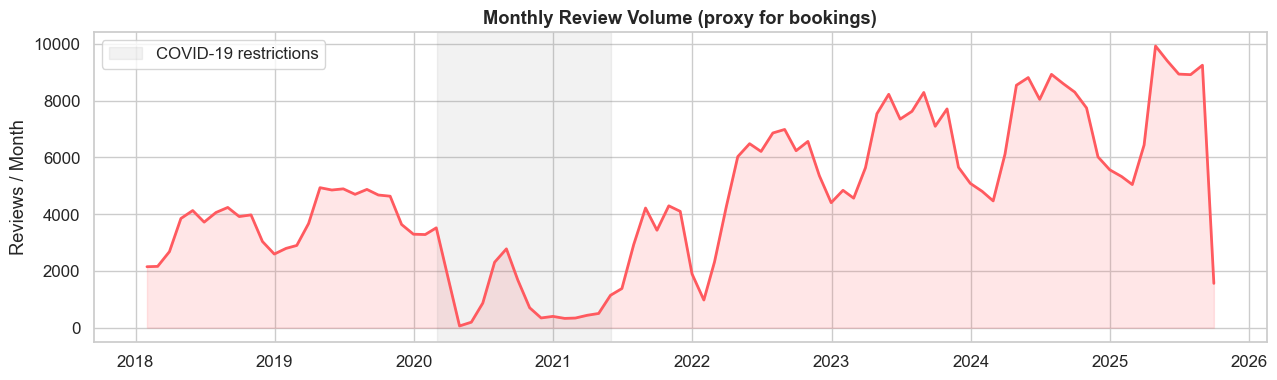

In [15]:
# ── 4.4 Monthly review volume — booking demand proxy ─────────────────────────
# Inside Airbnb: ~50-70% of stays generate a review — useful demand proxy
review_ts = (
    reviews_raw
    .assign(date=lambda x: pd.to_datetime(x['date'], errors='coerce'))
    .dropna(subset=['date'])
    .set_index('date')
    .resample('ME').size()
    .rename('review_count')
    .reset_index()
    .query('date >= "2018-01-01"')
)

fig, ax = plt.subplots(figsize=(13, 4))
sns.lineplot(data=review_ts, x='date', y='review_count', color='#FF5A5F', linewidth=2, ax=ax)
ax.fill_between(review_ts['date'], review_ts['review_count'], alpha=0.15, color='#FF5A5F')
# COVID dip is an important outlier to flag with domain knowledge
ax.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2021-06-01'),
           alpha=0.1, color='gray', label='COVID-19 restrictions')
ax.set_title('Monthly Review Volume (proxy for bookings)', fontweight='bold')
ax.set_xlabel(''); ax.set_ylabel('Reviews / Month'); ax.legend()
plt.tight_layout(); plt.show()

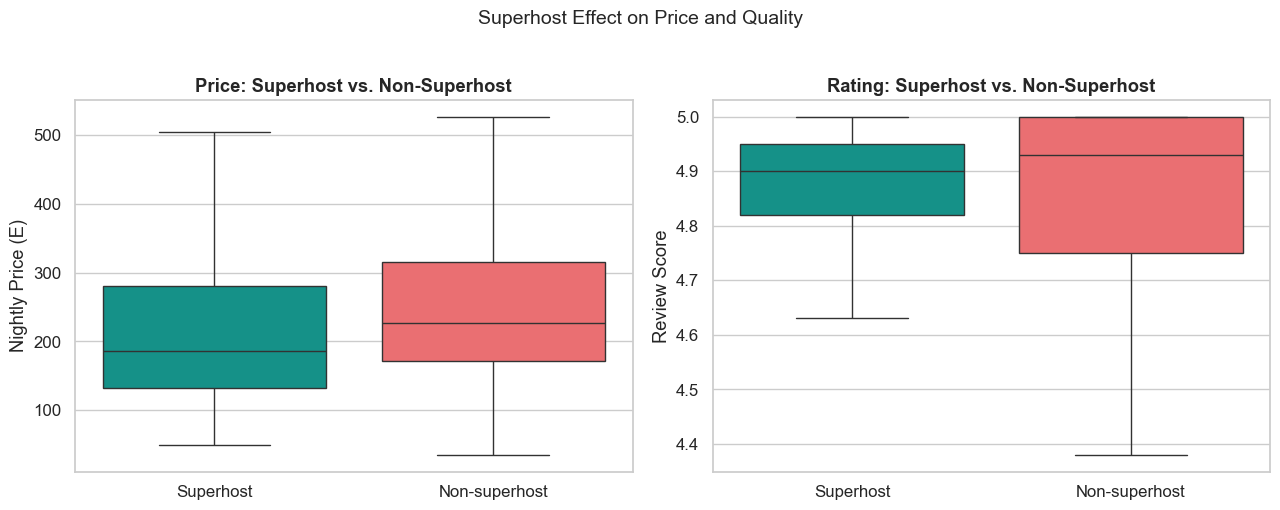

                 median_price  median_rating  n_obs
superhost_label                                    
Non-superhost          227.50           4.93   3676
Superhost              186.50           4.90   1448


In [8]:
# ── 4.5 Superhost vs. non-superhost: price and rating ────────────────────────
# Business question: does the Superhost badge justify a price premium?
superhost_comp = (
    df
    .assign(superhost_label=lambda x: x['is_superhost'].map({1: 'Superhost', 0: 'Non-superhost'}))
    .dropna(subset=['is_superhost', 'price', 'review_scores_rating'])
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.boxplot(data=superhost_comp, x='superhost_label', y='price',
            palette=['#00A699', '#FF5A5F'], showfliers=False, ax=axes[0])
axes[0].set_title('Price: Superhost vs. Non-Superhost', fontweight='bold')
axes[0].set_xlabel(''); axes[0].set_ylabel('Nightly Price (E)')

sns.boxplot(data=superhost_comp, x='superhost_label', y='review_scores_rating',
            palette=['#00A699', '#FF5A5F'], showfliers=False, ax=axes[1])
axes[1].set_title('Rating: Superhost vs. Non-Superhost', fontweight='bold')
axes[1].set_xlabel(''); axes[1].set_ylabel('Review Score')

plt.suptitle('Superhost Effect on Price and Quality', fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

result = (
    superhost_comp
    .groupby('superhost_label')[['price', 'review_scores_rating']]
    .agg(median_price=('price', 'median'),
         median_rating=('review_scores_rating', 'median'),
         n_obs=('price', 'count') )
    .round(2)
)
print(result)

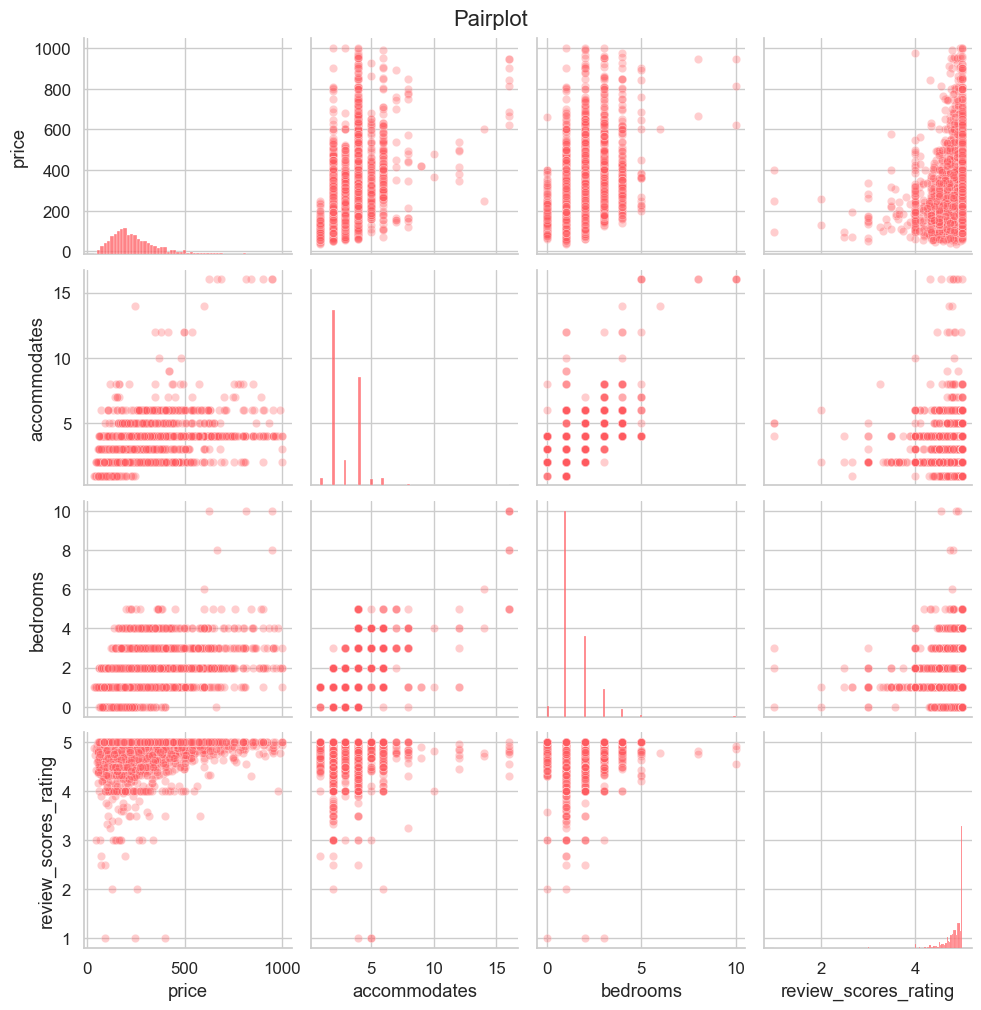

In [ ]:
# ── 4.6 YOUR EXPLORATION HERE ─────────────────────────────────────────────────
#
# Suggested additions for Exemplary grade:
#   • Pairplot: price, accommodates, bedrooms, review_scores_rating
# Example of pairplot
# sns.pairplot(
#     df[['price','accommodates','bedrooms','review_scores_rating']].dropna(),
#     plot_kws={'alpha': 0.3, 'color': '#FF5A5F'}
# )
# plt.suptitle('Pairplot', y=1.01); plt.show()



#   • minimum_nights distribution — do many hosts enforce 30+ night stays?
#   • Host listing count distribution — proportion of multi-listers
#   • Language distribution of reviews (English vs Dutch vs other)
#   • Sentiment of reviews  
#   • Seasonal price patterns if multiple months of data are available
#

pass

---
## 5. Pricing & Revenue Analysis
> Distribution analysis; subgroup comparisons by neighbourhood and room type.

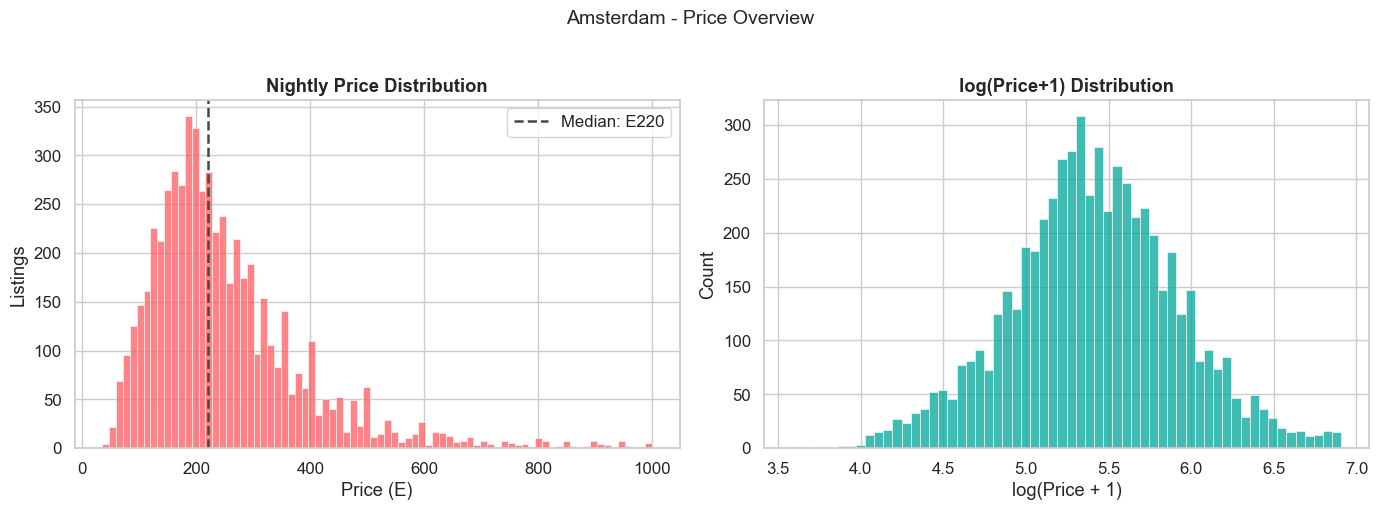

,E/night
count,5819.00
mean,253.17
std,139.87
min,35.00
25%,161.00
50%,220.00
75%,309.00
90%,425.00
95%,517.10
max,1000.00


In [9]:
# ── 5.1 Price distribution (raw and log) ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['price'], bins=80, color='#FF5A5F', edgecolor='white', linewidth=0.4, ax=axes[0])
axes[0].axvline(df['price'].median(), color='#484848', linestyle='--', linewidth=1.8,
                label=f'Median: E{df["price"].median():.0f}')
axes[0].set_title('Nightly Price Distribution', fontweight='bold')
axes[0].set_xlabel('Price (E)'); axes[0].set_ylabel('Listings'); axes[0].legend()

# Log-transformed: used as the ML target for better regression performance
sns.histplot(df['log_price'], bins=60, color='#00A699', edgecolor='white', linewidth=0.4, ax=axes[1])
axes[1].set_title('log(Price+1) Distribution', fontweight='bold')
axes[1].set_xlabel('log(Price + 1)')

plt.suptitle(f'{CITY_NAME} - Price Overview', fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

df['price'].describe(percentiles=[.25, .5, .75, .9, .95]).rename('E/night').to_frame()

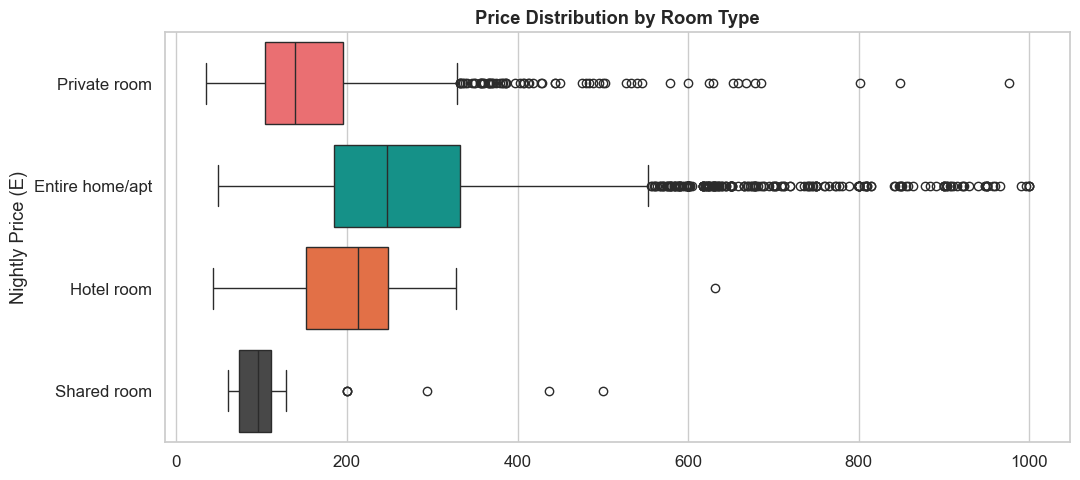

In [ ]:
# ── 5.2 Price by room type — violin shows full distribution shape ─────────────
fig, ax = plt.subplots(figsize=(11, 5))
sns.boxplot(data=df, 
    y='room_type', 
    x='price',
    palette=AIRBNB_PALETTE)
ax.set_title('Price Distribution by Room Type', fontweight='bold')
ax.set_xlabel(''); ax.set_ylabel('Nightly Price (E)')
plt.tight_layout(); plt.show()

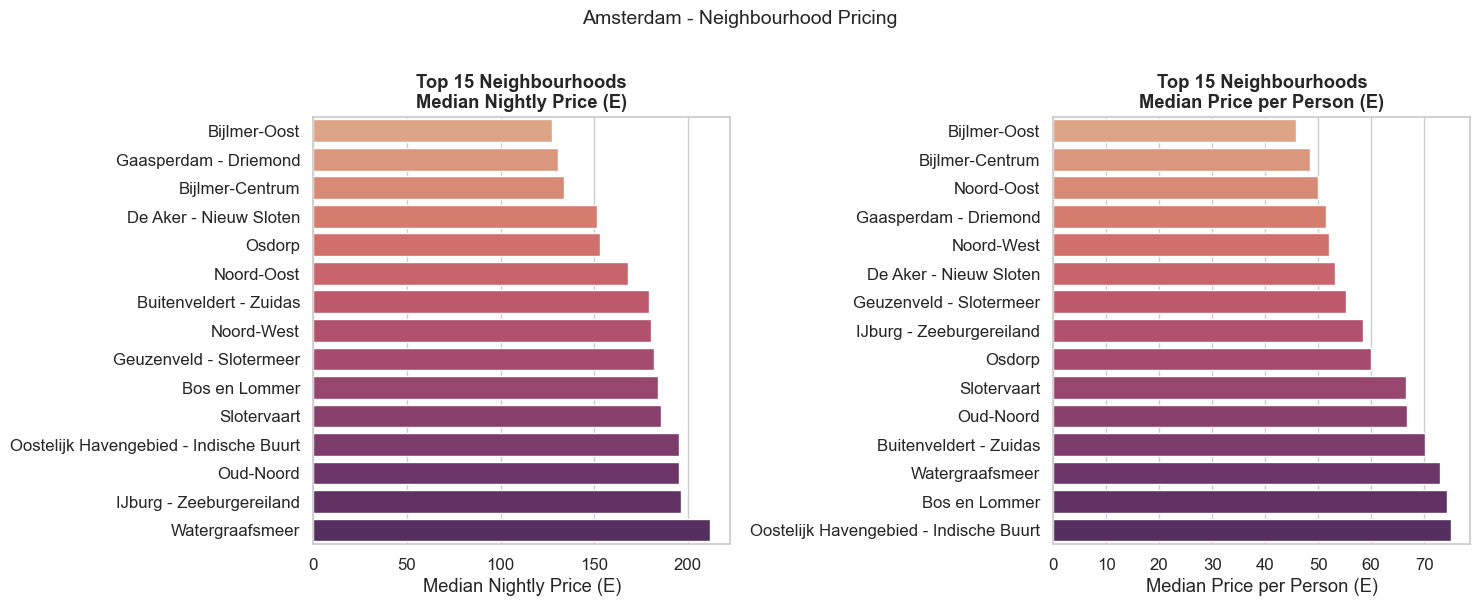

In [ ]:
# ── 5.3 Top neighbourhoods by median price ────────────────────────────────────
nbhd_price = (
    df
    .groupby('neighbourhood_cleansed', as_index=False)
    .agg(
        median_price        = ('price', 'median'),
        median_price_person = ('price_per_person', 'median'),
        n_listings          = ('price', 'count')
    )
    .query('n_listings >= 20')   # require min sample size for reliability
    .sort_values('median_price', ascending=False)
    .head(15)
)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, col, title in zip(
    axes,
    ['median_price', 'median_price_person'],
    ['Median Nightly Price (E)', 'Median Price per Person (E)']
):
    sns.barplot(data=nbhd_price.sort_values(col), x=col,
                y='neighbourhood_cleansed', palette='flare', ax=ax)
    ax.set_title(f'Top 15 Neighbourhoods\n{title}', fontweight='bold')
    ax.set_xlabel(title); ax.set_ylabel('')

plt.suptitle(f'{CITY_NAME} - Neighbourhood Pricing', fontsize=14, y=1.01)
plt.tight_layout(); plt.show()

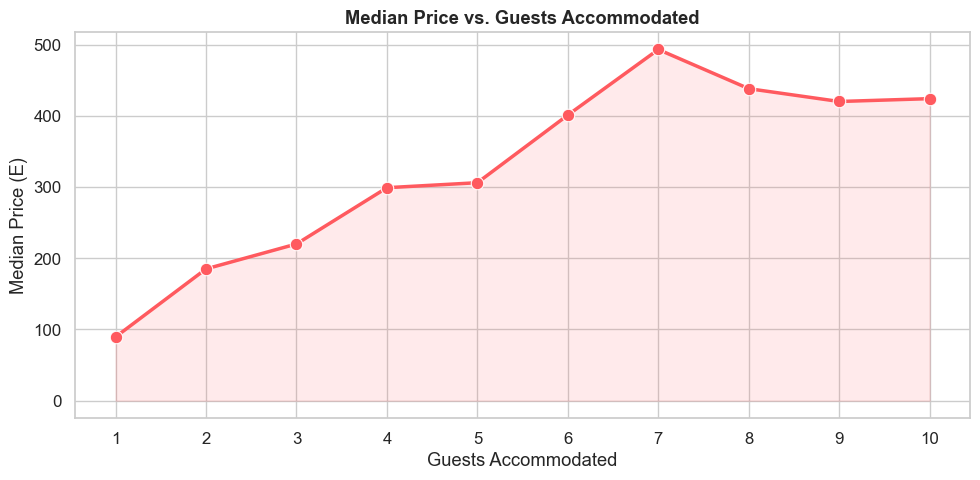

In [24]:
# ── 5.4 Price vs. guests accommodated ────────────────────────────────────────
acc_price = (
    df
    .query('accommodates <= 10')   # cap for readability; >10 is tiny segment
    .groupby('accommodates', as_index=False)
    .agg(median_price=('price', 'median'), n=('price', 'count'))
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.lineplot(data=acc_price, x='accommodates', y='median_price',
             marker='o', color='#FF5A5F', linewidth=2.5, markersize=9, ax=ax)
ax.fill_between(acc_price['accommodates'], acc_price['median_price'],
                alpha=0.12, color='#FF5A5F')
ax.set_title('Median Price vs. Guests Accommodated', fontweight='bold')
ax.set_xlabel('Guests Accommodated'); ax.set_ylabel('Median Price (E)')
ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.tight_layout(); plt.show()

---
## 6. Guest Reviews & Sentiment
> Statistical summaries + visualisations; subgroup comparisons; patterns identified.

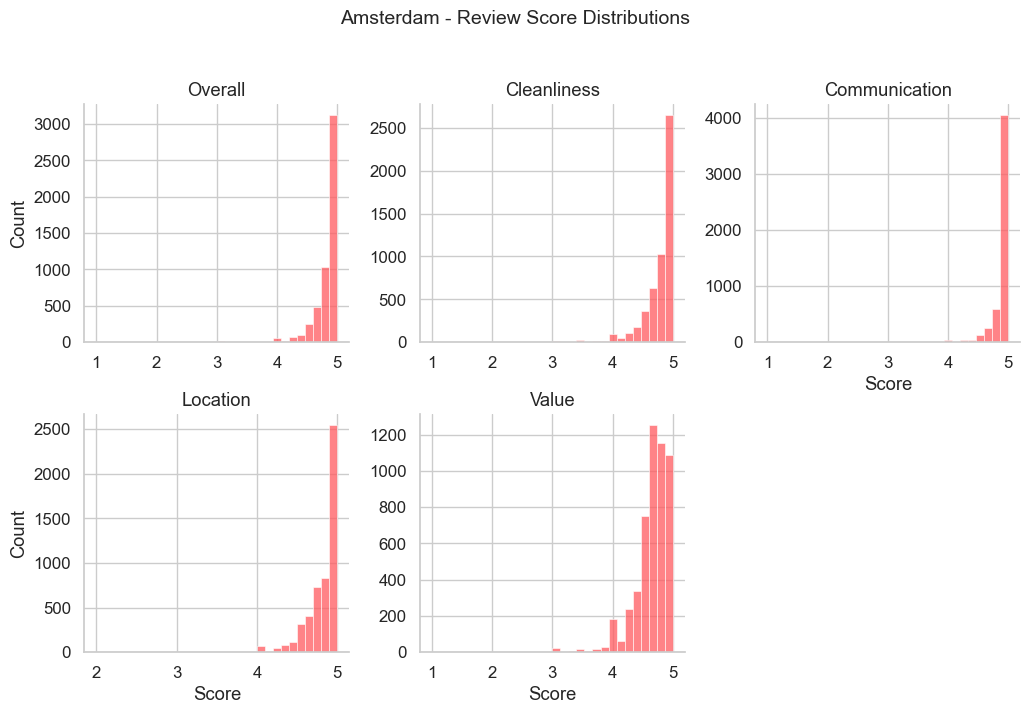

,Median Score
Overall,4.91
Cleanliness,4.88
Communication,4.98
Location,4.89
Value,4.70


In [10]:
# ── 6.1 Review score distributions — FacetGrid for all sub-scores ─────────────
score_cols = {
    'review_scores_rating': 'Overall', 'review_scores_cleanliness': 'Cleanliness',
    'review_scores_communication': 'Communication',
    'review_scores_location': 'Location', 'review_scores_value': 'Value'
}
score_cols = {k: v for k, v in score_cols.items() if k in df.columns}

scores_long = (
    df[list(score_cols.keys())]
    .rename(columns=score_cols)
    .melt(var_name='Category', value_name='Score')
    .dropna()
)

g = sns.FacetGrid(scores_long, col='Category', col_wrap=3, height=3.5, sharex=False, sharey=False)
g.map_dataframe(sns.histplot, x='Score', bins=30, color='#FF5A5F', edgecolor='white', linewidth=0.4)
g.set_titles(col_template='{col_name}')
g.set_axis_labels('Score', 'Count')
g.figure.suptitle(f'{CITY_NAME} - Review Score Distributions', y=1.02, fontsize=14)
plt.tight_layout(); plt.show()

df[list(score_cols.keys())].rename(columns=score_cols).median().rename('Median Score').to_frame()

In [12]:
(
    scores_long.groupby('Category')['Score']
    .describe()
    .round(3)
    .T  # Transpose for Category-as-columns layout
)

Category,Cleanliness,Communication,Location,Overall,Value
count,5178.00,5178.00,5178.00,5178.00,5178.00
mean,4.78,4.90,4.82,4.84,4.65
std,0.31,0.21,0.22,0.26,0.32
min,1.00,1.00,2.00,1.00,1.00
25%,4.70,4.89,4.74,4.78,4.52
50%,4.88,4.98,4.89,4.91,4.70
75%,5.00,5.00,5.00,5.00,4.83
max,5.00,5.00,5.00,5.00,5.00


Running TextBlob sentiment on sample of 5,000 reviews...


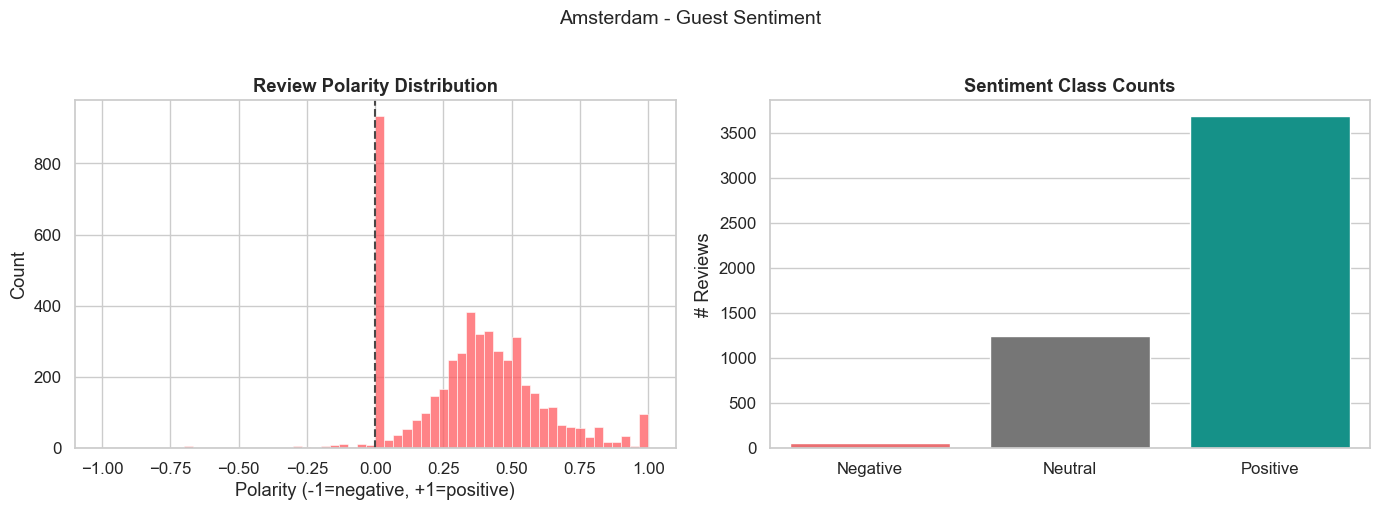

Mean polarity: 0.349


In [13]:
# ── 6.2 Sentiment analysis on review text ────────────────────────────────────
print('Running TextBlob sentiment on sample of 5,000 reviews...')

#  use the following libraries
# from textblob import TextBlob
# from wordcloud import WordCloud

reviews = (
    reviews_raw
    .dropna(subset=['comments'])
    .query('comments.str.len() > 20')
    .sample(min(5000, len(reviews_raw)), random_state=SEED)
    .assign(
        polarity     = lambda x: x['comments'].map(lambda t: TextBlob(str(t)).sentiment.polarity),
        subjectivity = lambda x: x['comments'].map(lambda t: TextBlob(str(t)).sentiment.subjectivity),
        sentiment    = lambda x: pd.cut(
            x['polarity'], bins=[-1, -0.05, 0.2, 1],
            labels=['Negative', 'Neutral', 'Positive']
        )
    )
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(reviews['polarity'], bins=60, color='#FF5A5F', edgecolor='white', linewidth=0.4, ax=axes[0])
axes[0].axvline(0, color='#484848', linestyle='--', linewidth=1.5)
axes[0].set_title('Review Polarity Distribution', fontweight='bold')
axes[0].set_xlabel('Polarity (-1=negative, +1=positive)')

pal = {'Positive': '#00A699', 'Neutral': '#767676', 'Negative': '#FF5A5F'}
sns.barplot(
    data=reviews['sentiment'].value_counts().reset_index(),
    x='sentiment', y='count', palette=pal, ax=axes[1]
)
axes[1].set_title('Sentiment Class Counts', fontweight='bold')
axes[1].set_xlabel(''); axes[1].set_ylabel('# Reviews')

plt.suptitle(f'{CITY_NAME} - Guest Sentiment', fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

print(f"Mean polarity: {reviews['polarity'].mean():.3f}")

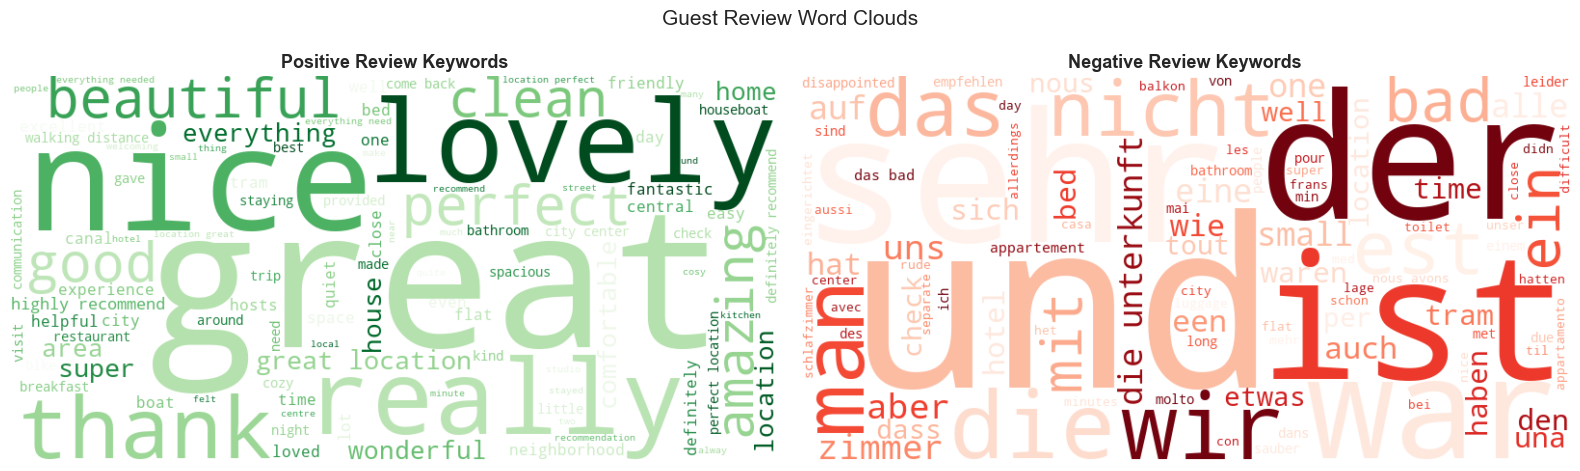

In [14]:
# ── 6.3 Word clouds: positive vs. negative ───────────────────────────────────
STOP_WORDS = {
    'the','and','was','for','with','this','that','are','very','our','from',
    'had','have','we','it','to','a','in','of','is','my','but','on','be',
    'at','as','an','by','were','has','not','so','they','their','us','all',
    'i','he','she','him','her','his','its','me','you','your','stay','would',
    'could','will','amsterdam','airbnb','apartment','room','place','host'
}

def build_wordcloud(texts, colormap):
    tokens = re.findall(r'\b[a-zA-Z]{3,}\b', ' '.join(texts).lower())
    clean  = ' '.join(w for w in tokens if w not in STOP_WORDS)
    return WordCloud(width=800, height=400, background_color='white',
                     colormap=colormap, max_words=100).generate(clean)

pos_texts = reviews.loc[reviews['sentiment'] == 'Positive', 'comments'].tolist()
neg_texts = reviews.loc[reviews['sentiment'] == 'Negative', 'comments'].tolist()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, texts, title, cmap in zip(
    axes, [pos_texts, neg_texts],
    ['Positive Review Keywords', 'Negative Review Keywords'], ['Greens', 'Reds']
):
    ax.imshow(build_wordcloud(texts, cmap), interpolation='bilinear')
    ax.set_title(title, fontweight='bold', fontsize=13); ax.axis('off')

plt.suptitle('Guest Review Word Clouds', fontsize=15)
plt.tight_layout(); plt.show()

---
## 7. Geographic & Neighbourhood Analysis
> Geographic variation explored; interactive maps with foliu; subgroup comparisons.

In [53]:
# ── 7.1 Neighbourhood summary table ──────────────────────────────────────────
nbhd_summary = (
    df
    .groupby('neighbourhood_cleansed', as_index=False)
    .agg(
        listings        = ('price', 'count'),
        median_price    = ('price', 'median'),
        avg_rating      = ('review_scores_rating', 'mean'),
        pct_superhost   = ('is_superhost', 'mean'),
        avg_host_tenure = ('host_age_years', 'mean')
    )
    .query('listings >= 15')
    .sort_values('median_price', ascending=False)
    .round(2)
)
print(f'{len(nbhd_summary)} neighbourhoods with >=15 listings')
nbhd_summary.head(15)

22 neighbourhoods with >=15 listings


,neighbourhood_cleansed,listings,median_price,avg_rating,pct_superhost,avg_host_tenure
8,De Pijp - Rivierenbuurt,648,250.00,4.86,0.22,9.32
5,Centrum-West,755,241.00,4.82,0.41,8.88
7,De Baarsjes - Oud-West,991,240.00,4.86,0.19,9.77
4,Centrum-Oost,573,237.00,4.82,0.34,9.08
21,Zuid,426,235.50,4.87,0.17,9.65
17,Oud-Oost,324,220.50,4.82,0.21,9.57
20,Westerpark,389,214.00,4.84,0.23,9.89
19,Watergraafsmeer,136,212.00,4.86,0.27,9.19
11,IJburg - Zeeburgereiland,104,196.50,4.87,0.32,9.33
14,Oostelijk Havengebied - Indische Buurt,231,195.00,4.85,0.22,9.82


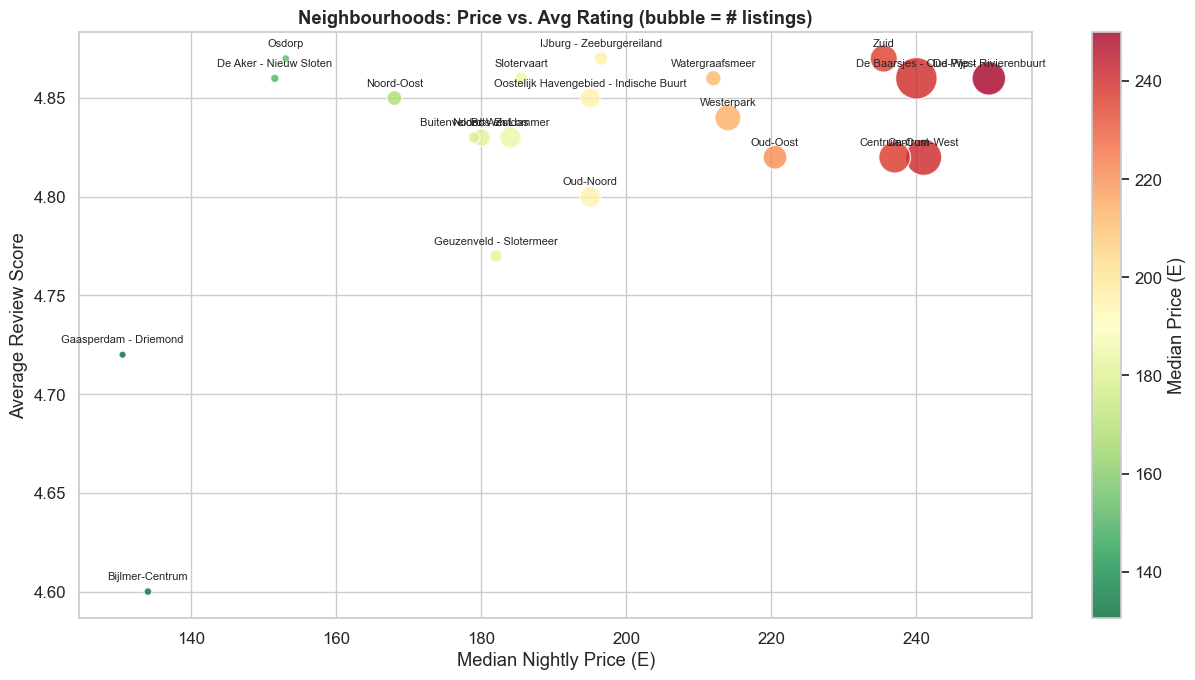

In [27]:
# ── 7.2 Bubble chart: price vs. rating, sized by volume ──────────────────────
bubble_df = nbhd_summary.query('listings >= 30').copy()

fig, ax = plt.subplots(figsize=(13, 7))
scatter = ax.scatter(
    bubble_df['median_price'], bubble_df['avg_rating'],
    s=bubble_df['listings'] / bubble_df['listings'].max() * 900,
    c=bubble_df['median_price'], cmap='RdYlGn_r', alpha=0.8, edgecolors='white', linewidths=1
)
plt.colorbar(scatter, ax=ax, label='Median Price (E)')
for _, row in bubble_df.iterrows():
    ax.annotate(row['neighbourhood_cleansed'], (row['median_price'], row['avg_rating']),
                fontsize=8, ha='center', va='bottom', xytext=(0, 7), textcoords='offset points')
ax.set_title('Neighbourhoods: Price vs. Avg Rating (bubble = # listings)', fontweight='bold')
ax.set_xlabel('Median Nightly Price (E)'); ax.set_ylabel('Average Review Score')
plt.tight_layout(); plt.show()

In [ ]:
# ── 7.3 Interactive map: listings by price tier ───────────────────────────────
map_sample = (
    df.dropna(subset=['latitude', 'longitude', 'price'])
      .sample(min(3000, len(df)), random_state=SEED)
)
center = [map_sample['latitude'].mean(), map_sample['longitude'].mean()]
m = folium.Map(location=center, zoom_start=13, tiles='CartoDB positron')
q33, q66 = map_sample['price'].quantile([0.33, 0.66])

def price_color(p):
    if p < q33:   return '#00A699'
    elif p < q66: return '#FFB400'
    return '#FF5A5F'

mc = MarkerCluster(disableClusteringAtZoom=14).add_to(m)
for _, row in map_sample.iterrows():
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']], radius=5,
        color=price_color(row['price']), fill=True, fill_opacity=0.75,
        popup=folium.Popup(f"E{row['price']:.0f}/night | {row.get('room_type','')}", max_width=200)
    ).add_to(mc)

m.get_root().html.add_child(folium.Element(f'''
<div style="position:fixed;bottom:30px;left:30px;z-index:1000;
background:white;padding:12px;border-radius:8px;border:1px solid #ccc;font-size:13px">
  <b>Price/night</b><br>
  <span style="color:#00A699">o</span> &lt; E{q33:.0f}<br>
  <span style="color:#FFB400">o</span> E{q33:.0f}-E{q66:.0f}<br>
  <span style="color:#FF5A5F">o</span> &gt; E{q66:.0f}
</div>'''))
m.save('listings_map.html')
print('Interactive map saved to listings_map.html')
m

In [ ]:
# ── 7.4 Price heatmap ────────────────────────────────────────────────────────
hmap = folium.Map(location=center, zoom_start=13, tiles='CartoDB positron')
HeatMap(
    map_sample[['latitude','longitude','price']].values.tolist(),
    radius=12, blur=14, min_opacity=0.35,
    gradient={0.2:'#00A699', 0.5:'#FFB400', 0.8:'#FF5A5F', 1:'#8B0000'}
).add_to(hmap)
hmap.save('price_heatmap.html')
print('Heatmap saved to price_heatmap.html')
hmap

In [ ]:
# ── 7.5 Choropleth: median price/night by neighbourhood ──────────────────────

# Compute median price per neighbourhood — chain produces a clean lookup table
nbhd_median = (
    df
    .groupby('neighbourhood_cleansed', as_index=False)
    .agg(median_price=('price', 'median'), n_listings=('price', 'count'))
    .query('n_listings >= 10')          # drop tiny neighbourhoods (noisy medians)
    .rename(columns={'neighbourhood_cleansed': 'neighbourhood'})
)

# Download GeoJSON (small file, no gz)
geo = requests.get(GEOJSON_URL, timeout=30).json()

# Build choropleth — folium.Choropleth handles the colour scale automatically
choropleth_map = folium.Map(
    location=[df['latitude'].mean(), df['longitude'].mean()],
    zoom_start=12,
    tiles='CartoDB positron'
)

choropleth = folium.Choropleth(
    geo_data=geo,
    data=nbhd_median,
    columns=['neighbourhood', 'median_price'],   # key col, value col
    key_on='feature.properties.neighbourhood',   # must match GeoJSON property name
    fill_color='YlOrRd',                         # yellow→orange→red = low→high price
    fill_opacity=0.75,
    line_opacity=0.4,
    legend_name='Median Nightly Price (€)',
    highlight=True,                              # highlight neighbourhood on hover
    nan_fill_color='lightgrey',                  # colour for neighbourhoods with no data
).add_to(choropleth_map)

# Add neighbourhood name + median price as a tooltip on hover
choropleth.geojson.add_child(
    folium.features.GeoJsonTooltip(
        fields=['neighbourhood'],
        aliases=['Neighbourhood:'],
        style='font-size:13px; font-weight:bold;'
    )
)

# Overlay the median price from our dataframe as a second tooltip layer
# (GeoJSON tooltip can only read properties that live in the GeoJSON itself,
#  so we inject the price into each feature's properties first)
price_lookup = nbhd_median.set_index('neighbourhood')['median_price'].to_dict()

for feature in geo['features']:
    nbhd = feature['properties'].get('neighbourhood', '')
    feature['properties']['median_price'] = (
        f"€{price_lookup[nbhd]:.0f}" if nbhd in price_lookup else 'n/a'
    )

folium.GeoJson(
    geo,
    style_function=lambda x: {'fillOpacity': 0, 'weight': 0},   # invisible — tooltip only
    tooltip=folium.GeoJsonTooltip(
        fields=['neighbourhood', 'median_price'],
        aliases=['Neighbourhood:', 'Median price/night:'],
        style='font-size:13px;'
    )
).add_to(choropleth_map)

folium.LayerControl().add_to(choropleth_map)
choropleth_map.save('choropleth_price.html')
print('✅ Choropleth saved → choropleth_price.html')
choropleth_map

In [ ]:
# ── 7.6 Interactive listing map — click a dot to open the Airbnb listing ──────
# Each listing on Inside Airbnb has a stable URL:
# https://www.airbnb.com/rooms/<listing_id>
# We build that URL and embed it in a folium Popup so clicking opens the page.

# Sample to keep the map snappy in the notebook — remove .sample() for the full set
map_df = (
    df
    .dropna(subset=['latitude', 'longitude', 'price', 'id'])
    .assign(
        # Airbnb listing URL — constructed from the listing id
        listing_url=lambda x: 'https://www.airbnb.com/rooms/' + x['id'].astype(str),
        # Clip long names so the popup stays readable
        display_name=lambda x: x['name'].fillna('Unnamed listing').str[:60],
    )
    .sample(min(4000, len(df)), random_state=SEED)   # 4k dots renders fast
)

# Colour dots by price tertile so spatial price patterns are visible at a glance
q33, q66 = map_df['price'].quantile([0.33, 0.66])

def dot_color(price):
    if price <= q33:   return '#00A699'   # teal  = budget
    elif price <= q66: return '#FFB400'   # amber = mid-range
    else:              return '#FF5A5F'   # red   = premium

listing_map = folium.Map(
    location=[map_df['latitude'].mean(), map_df['longitude'].mean()],
    zoom_start=13,
    tiles='CartoDB positron'
)

# Use MarkerCluster so dots merge at low zoom and separate as you zoom in
cluster = MarkerCluster(
    options={
        'maxClusterRadius': 40,          # pixels before dots merge
        'disableClusteringAtZoom': 15,   # show individual dots at street level
    }
).add_to(listing_map)

for _, row in map_df.iterrows():
    # HTML popup — clicking "View listing" opens Airbnb in a new tab
    popup_html = f"""
    <div style="font-family:Arial,sans-serif;font-size:13px;width:220px;">
      <b style="font-size:14px;">{row['display_name']}</b><br>
      <span style="color:#FF5A5F;font-size:16px;font-weight:bold;">
        €{row['price']:.0f}/night
      </span><br>
      <span style="color:#767676;">{row.get('room_type','')}</span><br>
      <span style="color:#767676;">
        ⭐ {row['review_scores_rating']:.1f}
      </span>
      &nbsp;·&nbsp;
      <span style="color:#767676;">
        {int(row['number_of_reviews'])} reviews
      </span><br><br>
      <a href="{row['listing_url']}" target="_blank"
         style="background:#FF5A5F;color:white;padding:5px 12px;
                border-radius:4px;text-decoration:none;font-weight:bold;">
        View listing ↗
      </a>
    </div>
    """

    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=5,
        color='white',
        weight=0.8,
        fill=True,
        fill_color=dot_color(row['price']),
        fill_opacity=0.85,
        popup=folium.Popup(popup_html, max_width=250),
        tooltip=f"€{row['price']:.0f}/night — click for details",
    ).add_to(cluster)

# Legend
legend_html = f"""
<div style="position:fixed;bottom:30px;left:30px;z-index:1000;
     background:white;padding:12px 16px;border-radius:8px;
     border:1px solid #ddd;font-family:Arial,sans-serif;font-size:13px;">
  <b>Price / night</b><br>
  <span style="color:#00A699;font-size:18px;">●</span> Budget (&lt; €{q33:.0f})<br>
  <span style="color:#FFB400;font-size:18px;">●</span> Mid (€{q33:.0f}–€{q66:.0f})<br>
  <span style="color:#FF5A5F;font-size:18px;">●</span> Premium (&gt; €{q66:.0f})<br>
  <span style="color:#999;font-size:11px;">Click any dot to open listing</span>
</div>"""
listing_map.get_root().html.add_child(folium.Element(legend_html))

listing_map.save('listings_clickable.html')
print(f'✅ Map saved → listings_clickable.html  ({len(map_df):,} listings plotted)')
listing_map

---
## 8. Machine Learning — Linear Regression (Baseline)
> Full sklearn Pipeline (imputation + encoding + scaling INSIDE CV folds — no leakage); written model justification; CV comparison; test-set evaluation with residual plot.

